In [76]:
from half_linac.apps.emit_measure.main import transfer as map
import epics
import numpy as np
import json
import half_linac.setup as st
import matplotlib.pyplot as plt
import time

bpm2_x = epics.PV("IRFEL:BD:BPM02:X")
bpm2_y = epics.PV("IRFEL:BD:BPM02:Y")

bpm3_x = epics.PV("IRFEL:BD:BPM03:X")
bpm3_y = epics.PV("IRFEL:BD:BPM03:Y")

bpm7_x = epics.PV("IRFEL:BD:BPM07:X")
bpm7_y = epics.PV("IRFEL:BD:BPM07:Y")

quad = epics.PV("IRFEL:AP:QUAD:CQ1:K1:ao")
#-------------------------
steps = 10
samples = 3
#----------------------------
#----------------------------
bpm1 = bpm2_y
bpm2 = bpm3_y
plane = "y"
cor = epics.PV("IRFEL:PS:VC01:current:ao")

k1_ini = -28.7
kick_ini = 0.9

k1l = np.linspace(-33,-23,steps)
kickl = np.linspace(-1,3,steps)
#----------------------------
#----------------------------

K1= -28.7
m2= 2.45 mm
m2= 2.45 mm
m2= 1.82 mm
m2= 3.29 mm
m2= 2.5 mm
m2= 2.61 mm
m2= 3.01 mm
m2= 3.19 mm
m2= 3.1 mm
m2= 2.96 mm
m2= 2.15 mm
m2= 2.99 mm
m2= 2.83 mm
m2= 2.37 mm
m2= 1.87 mm
m2= 3.12 mm
m2= 3.26 mm
m2= 2.97 mm
m2= 2.7 mm
m2= 3.01 mm
m2= 3.25 mm
m2= 1.97 mm
m2= 2.43 mm
m2= 3.68 mm
m2= 3.04 mm
m2= 3.22 mm
m2= 3.58 mm
m2= 3.3 mm
m2= 3.6 mm
m2= 3.59 mm
 
-0.001559 x + 0.005058
S= -0.0015585337818181796
m1_ave= 0.89 mm


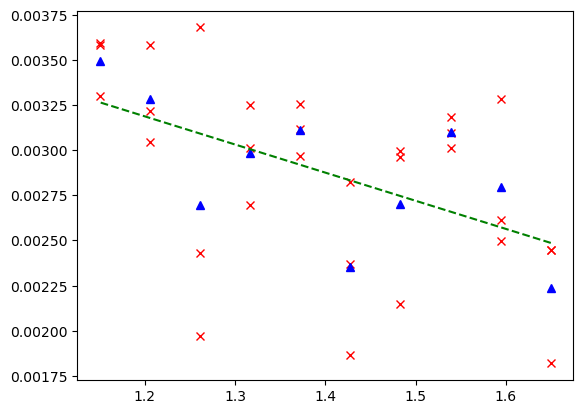

In [77]:
quad.put(k1_ini)
time.sleep(5)
inival_quad = quad.get()
print("K1=",inival_quad)

if plane == "x":
    abc = 1
else:
    abc = -1

plt.figure()  
m2 = []
for k1 in k1l:
    quad.put(k1)
    # time.sleep(5)
    for j in range(samples):
        time.sleep(5)
    
        mm2 = bpm2.get()*1e-3
        print("m2=",round(mm2*1e3,2),"mm")
        plt.plot(k1*abc*0.05,mm2,"xr")
        m2.append(mm2)

# fitting
m2_mat = np.reshape(m2,(steps,samples))        
m2_ave = np.mean(m2_mat,1)

x = abc*k1l*0.05
y = np.array(m2_ave)

z1 = np.polyfit(x,y,deg=1)
p1 = np.poly1d(z1)
print(p1)
yvals = p1(x)

# plt.figure()
plt.plot(x,y,'b^')
plt.plot(x,yvals,'g--')

S = z1[0]
print("S=",S)

m1= []
for j in range(samples):
    mm1 = bpm1.get()*1e-3
    m1.append(mm1)

    time.sleep(3)
    
m1_ave = np.mean(m1)
print("m1_ave=",round(m1_ave*1e3,2),"mm")

quad.put(inival_quad)
cor.put(kick_ini)
plt.show()

ini_kick= -6.0
m2= 2.96 mm
m2= 3.46 mm
m2= 3.5 mm
m2= 3.48 mm
m2= 3.36 mm
m2= 3.14 mm
m2= 3.37 mm
m2= 2.61 mm
m2= 2.53 mm
m2= 2.65 mm
m2= 2.65 mm
m2= 3.18 mm
m2= 2.53 mm
m2= 2.39 mm
m2= 3.56 mm
m2= 3.56 mm
m2= 2.91 mm
m2= 3.0 mm
m2= 2.46 mm
m2= 3.03 mm
m2= 2.52 mm
m2= 2.11 mm
m2= 2.12 mm
m2= 2.23 mm
m2= 2.59 mm
m2= 2.78 mm
m2= 3.01 mm
m2= 2.55 mm
m2= 2.31 mm
m2= 1.98 mm
 
8.254 x + 0.001828
R12= 8.25 m


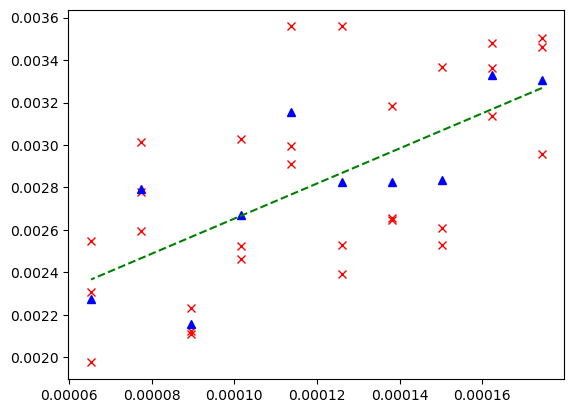

In [69]:
cor.put(kick_ini)

time.sleep(5)
inival_kick = cor.get()

print("ini_kick=",inival_kick)

# current to angle[rad]
current = kickl
By = (-0.4813*current-0.7747)*1e-4 #[T]
Leff = 0.05828673
anglel = 299.8/30.8*By*Leff

m2 = []
plt.figure()
k = 0
for kick in kickl:
    cor.put(kick)

    for j in range(samples):
        time.sleep(5)
    
        mm2 = bpm2.get()*1e-3
        print("m2=",round(mm2*1e3,2),"mm")    
        m2.append(mm2)
        plt.plot(anglel[k],mm2,"xr")   
    
    k = k+1    
        
# fitting
m2_mat = np.reshape(m2,(steps,samples))
m2_ave = np.mean(m2_mat,1)

x = anglel
y = m2_ave

z1 = np.polyfit(x,y,deg=1)
p1 = np.poly1d(z1)
print(p1)
yvals = p1(x)

plt.plot(x,y,'b^')
plt.plot(x,yvals,'g--')

R12 = z1[0]
print("R12=",round(R12,2),"m")

cor.put(inival_kick)
plt.show()

In [66]:
b1mq1=(S/R12-m1_ave) *1e3

print("b1-q1=", round(b1mq1,1),"mm")

b1-q1= 5.2 mm
